In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Sklearn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

In [2]:
#load dataset
data_url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/crop_recommendation/train_set_label.csv"
df = pd.read_csv(data_url)

print(df.head()) 

       N      P      K  temperature   humidity        ph    rainfall      crop
0   17.0  136.0  196.0    23.871923  90.499390  5.882156  103.054809     apple
1   49.0   69.0   82.0    18.315615  15.361435  7.263119   81.787105  chickpea
2   74.0   49.0   38.0    23.314104  71.450905  7.488014  164.497037      jute
3  104.0   35.0   28.0    27.510061  50.666872  6.983732  143.995555    coffee
4   23.0   72.0   84.0    19.020613  17.131591  6.920251   79.926981  chickpea


In [3]:
#data preprocess
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X = df[feature_cols]
y = df['crop']

#encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [4]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
#initialize model
model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    criterion='gini',
    random_state=42
)

#model training
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [6]:
#model eval
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9667
Precision: 0.9734
Recall: 0.9667
F1 Score: 0.9668


In [31]:
param_grid = {
    'max_depth': [5, 10, 20, 50],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [2, 4],
    'criterion': ['gini', 'entropy'],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters: ", grid_search.best_params_)
print("Best accuracy: ", grid_search.best_score_)

# Make predictions on test set
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)

# Evaluate
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, average='weighted')
recall_final = recall_score(y_test, y_pred_final, average='weighted')
f1_final = f1_score(y_test, y_pred_final, average='weighted')

print(f"Accuracy: {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall: {recall_final:.4f}")
print(f"F1 Score: {f1_final:.4f}")


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters:  {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 7}
Best accuracy:  0.9787878787878788
Accuracy: 0.9697
Precision: 0.9741
Recall: 0.9697
F1 Score: 0.9694


In [8]:
#cross validation
cv_scores = cross_val_score(model, X_train, y_train, cv=4, scoring='accuracy')

print('cv_scores', cv_scores)
print('avg accuracy', cv_scores.mean().round(4))

cv_scores [0.97272727 0.98787879 0.97575758 0.98181818]
avg accuracy 0.9795


Text(70.72222222222221, 0.5, 'True Label')

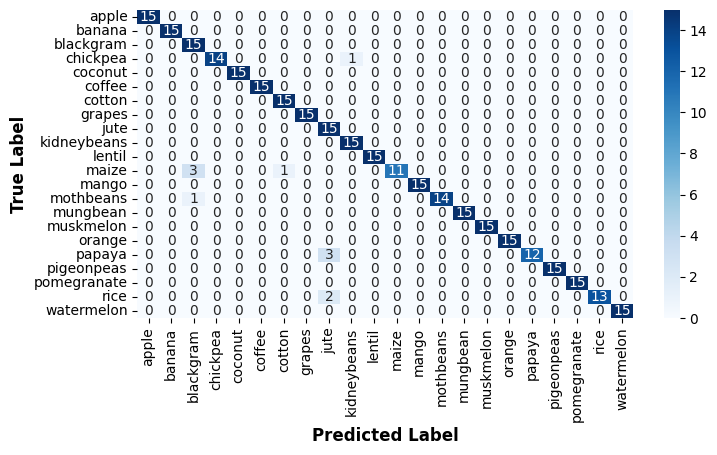

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
# plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')

       Feature  Importance
6     rainfall    0.313995
4     humidity    0.230640
1            P    0.200279
2            K    0.098839
0            N    0.093438
5           ph    0.062029
3  temperature    0.000780


<BarContainer object of 7 artists>

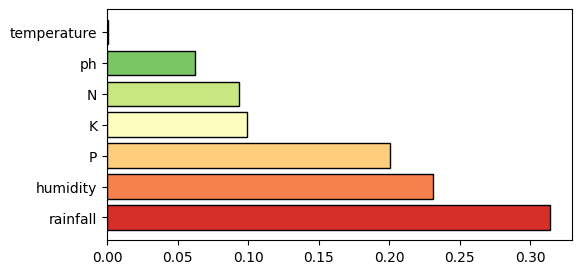

In [17]:
#feature importance
importance = model.feature_importances_
# # print(importance)
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values('Importance', ascending=False)
print(importance_df)

# Plot
plt.figure(figsize=(6, 3))
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(feature_cols)))
plt.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='black')

[Text(0.3181818181818182, 0.9, 'rainfall <= 30.849\ngini = 0.955\nsamples = 1320\nvalue = [60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60\n60, 60, 60, 60, 60, 60, 60, 60, 60, 60]\nclass = apple'),
 Text(0.22727272727272727, 0.7, 'gini = 0.0\nsamples = 60\nvalue = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0\n0, 60, 0, 0, 0, 0, 0, 0]\nclass = muskmelon'),
 Text(0.2727272727272727, 0.8, 'True  '),
 Text(0.4090909090909091, 0.7, 'humidity <= 27.685\ngini = 0.952\nsamples = 1260\nvalue = [60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60\n60, 60, 60, 0, 60, 60, 60, 60, 60, 60]\nclass = apple'),
 Text(0.36363636363636365, 0.8, '  False'),
 Text(0.18181818181818182, 0.5, 'ph <= 6.025\ngini = 0.5\nsamples = 120\nvalue = [0, 0, 0, 60, 0, 0, 0, 0, 0, 60, 0, 0, 0, 0\n0, 0, 0, 0, 0, 0, 0, 0]\nclass = chickpea'),
 Text(0.09090909090909091, 0.3, 'gini = 0.0\nsamples = 60\nvalue = [0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 0, 0, 0, 0\n0, 0, 0, 0, 0, 0, 0, 0]\nclass = kidneybeans'),
 Text(0.2727272727272727, 0.3, 'gi

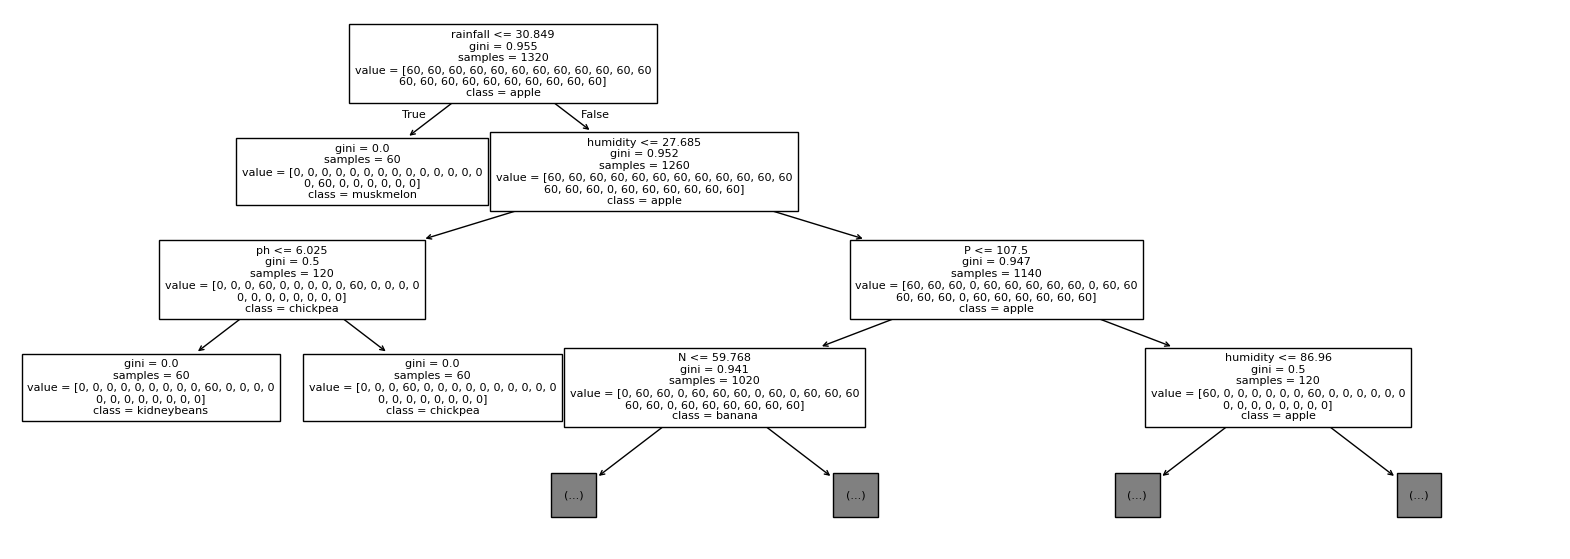

In [18]:
# decision tree
plt.figure(figsize=(20, 7))
plot_tree(
    model,
    feature_names=feature_cols,
    class_names=label_encoder.classes_.tolist(),
    fontsize=8,
    max_depth=3  # Show only first 3 levels for readability
)

In [32]:
import joblib
from pathlib import Path

model_obj = globals().get("best_model")
output_path = Path("../../models/decision_tree.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_obj, output_path)
print(f"Saved model to: {output_path.resolve()}")

Saved model to: /media/kushagra/DATA/notebook/crop-recommendation-ml-system/models/decision_tree.pkl


In [33]:
sample_input = [[17.0,  136.0,  196.0,    23.871923,  90.499390,  5.882156,  103.054809]]  # N, P, K, temperature, humidity, ph, rainfall
prediction = best_model.predict(sample_input)
print(f"Predicted crop: {label_encoder.inverse_transform([prediction[0]])[0]}")

Predicted crop: apple


/media/kushagra/DATA/notebook/crop-recommendation-ml-system/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
